In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("C:\\Users\\DELL\\Desktop\\Prime aiml\\Deeplearning\\ANNS\\data\\Powerplant dataset.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
df.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop(['PE'],axis = 1)
y = df['PE']

### Steps involved in creating ANN

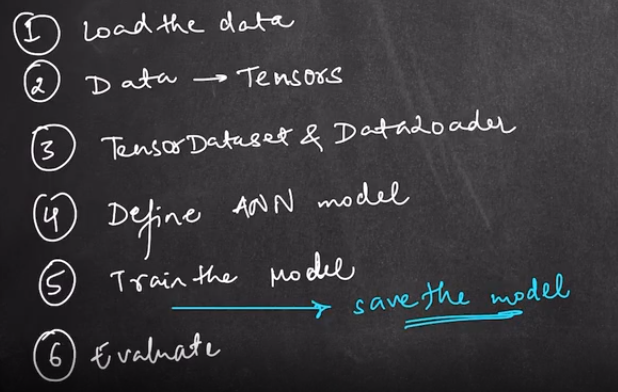

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [9]:
import torch
import torch.nn as nn

In [10]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=float)
X_test_tensor = torch.tensor(X_test_scaled, dtype=float)
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]], dtype=torch.float64)

In [11]:
y_train_tensor = torch.tensor(y_train.values, dtype = float).view(-1,1)   # values : y_train is in series form we only need to pass the numpy array , view = np.reshape
y_test_tensor = torch.tensor(y_test.values, dtype = float).view(-1,1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

In [13]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### DeepLearning

In [15]:
## Define our model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # First hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # Second hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Third hidden layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [17]:
import torch.optim as optim

model = ANN()

## Loss / Optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())